# NFL Home-Field Advantage: 2016–2025

**Research question:** How does home-field advantage vary across NFL seasons throughout the last 10 years?

This notebook uses the nflverse games/schedules dataset. The dataset is publicly maintained and provides game-level schedule/results data.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# Download the NFL game/schedule data
url = "https://github.com/nflverse/nflverse-data/releases/download/schedules/games.csv"

df = pd.read_csv(url)

# Filter the dataset to include only games from the 2016–2025 seasons
df = df[df["season"].between(2016, 2025)].copy()

print(f"Total games loaded: {len(df):,}")
print(f"Seasons: {df['season'].min()}–{df['season'].max()}")
df.head()

Total games loaded: 2,761
Seasons: 2016–2025


,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
4515,2016_01_CAR_DEN,2016,REG,1,2016-09-08,Thursday,20:30,CAR,20.0,DEN,...,10.0,00-0027939,00-0032156,Cam Newton,Trevor Siemian,Ron Rivera,Gary Kubiak,Gene Steratore,DEN00,Sports Authority Field at Mile High
4516,2016_01_TB_ATL,2016,REG,1,2016-09-11,Sunday,13:00,TB,31.0,ATL,...,NaN,00-0031503,00-0026143,Jameis Winston,Matt Ryan,Dirk Koetter,Dan Quinn,Jeff Triplette,ATL00,Georgia Dome
4517,2016_01_BUF_BAL,2016,REG,1,2016-09-11,Sunday,13:00,BUF,7.0,BAL,...,8.0,00-0028118,00-0026158,Tyrod Taylor,Joe Flacco,Rex Ryan,John Harbaugh,Brad Allen,BAL00,M&T Bank Stadium
4518,2016_01_CHI_HOU,2016,REG,1,2016-09-11,Sunday,13:00,CHI,14.0,HOU,...,NaN,00-0024226,00-0029682,Jay Cutler,Brock Osweiler,John Fox,Bill O'Brien,Peter Morelli,HOU00,NRG Stadium
4519,2016_01_GB_JAX,2016,REG,1,2016-09-11,Sunday,13:00,GB,27.0,JAX,...,3.0,00-0023459,00-0031407,Aaron Rodgers,Blake Bortles,Mike McCarthy,Gus Bradley,Carl Cheffers,JAX00,EverBank Field


In [19]:
print("Original columns:")
print(df.columns.tolist())

Original columns:
['game_id', 'season', 'game_type', 'week', 'gameday', 'weekday', 'gametime', 'away_team', 'away_score', 'home_team', 'home_score', 'location', 'result', 'total', 'overtime', 'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'away_rest', 'home_rest', 'away_moneyline', 'home_moneyline', 'spread_line', 'away_spread_odds', 'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'div_game', 'roof', 'surface', 'temp', 'wind', 'away_qb_id', 'home_qb_id', 'away_qb_name', 'home_qb_name', 'away_coach', 'home_coach', 'referee', 'stadium_id', 'stadium']


In [20]:
df = df[
    [
        "season",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "result",
        "location",
        "stadium",
        "game_type"
    ]
]

print("\nColumns after cleaning:")
print(df.columns.tolist())


Columns after cleaning:
['season', 'home_team', 'away_team', 'home_score', 'away_score', 'result', 'location', 'stadium', 'game_type']


In [21]:
# Select the variables used in the project
final_df = pd.DataFrame({
    "Season": df["season"],
    "Home Team": df["home_team"],
    "Away Team": df["away_team"],
    "Home Score": df["home_score"],
    "Away Score": df["away_score"],
    "Location": df["stadium"],
    "Season Type": df["game_type"]
})

final_df.head()

,Season,Home Team,Away Team,Home Score,Away Score,Location,Season Type
4515,2016,DEN,CAR,21.0,20.0,Sports Authority Field at Mile High,REG
4516,2016,ATL,TB,24.0,31.0,Georgia Dome,REG
4517,2016,BAL,BUF,13.0,7.0,M&T Bank Stadium,REG
4518,2016,HOU,CHI,23.0,14.0,NRG Stadium,REG
4519,2016,JAX,GB,23.0,27.0,EverBank Field,REG


In [22]:
print(df.shape)

(2761, 9)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2761 entries, 4515 to 7275
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      2761 non-null   int64  
 1   home_team   2761 non-null   object 
 2   away_team   2761 non-null   object 
 3   home_score  2761 non-null   float64
 4   away_score  2761 non-null   float64
 5   result      2761 non-null   float64
 6   location    2761 non-null   object 
 7   stadium     2761 non-null   object 
 8   game_type   2761 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 215.7+ KB


In [24]:
# Create the game result
def get_result(row):
    if row["Home Score"] > row["Away Score"]:
        return "Home Win"
    elif row["Home Score"] < row["Away Score"]:
        return "Away Win"
    else:
        return "Tie"

final_df["Game Result"] = final_df.apply(get_result, axis=1)

# Keep regular-season games only
final_df = final_df[final_df["Season Type"] == "REG"].copy()

print("Regular-season games by year:")
print(final_df["Season"].value_counts().sort_index())

Regular-season games by year:
Season
2016    256
2017    256
2018    256
2019    256
2020    256
2021    272
2022    271
2023    272
2024    272
2025    272
Name: count, dtype: int64


In [25]:
# Calculate home-team point differential
final_df["Point Differential"] = final_df["Home Score"] - final_df["Away Score"]

# Calculate home-team win percentage by season
home_win_percentage = (
    final_df.groupby("Season")["Game Result"]
    .apply(lambda x: (x == "Home Win").mean() * 100)
    .reset_index(name="Home Win Percentage")
    .sort_values("Season")
)

print(home_win_percentage.to_string(index=False))

 Season  Home Win Percentage
   2016            57.421875
   2017            56.640625
   2018            59.765625
   2019            51.562500
   2020            49.609375
   2021            51.470588
   2022            55.719557
   2023            55.514706
   2024            53.308824
   2025            53.676471


In [26]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [27]:
print("\nCleaned dataset:")
print(df.head())

print("\nFinal number of rows:", len(df))
print("Final number of columns:", len(df.columns))


Cleaned dataset:
      season home_team away_team  home_score  away_score  result location  \
4515    2016       DEN       CAR        21.0        20.0     1.0     Home   
4516    2016       ATL        TB        24.0        31.0    -7.0     Home   
4517    2016       BAL       BUF        13.0         7.0     6.0     Home   
4518    2016       HOU       CHI        23.0        14.0     9.0     Home   
4519    2016       JAX        GB        23.0        27.0    -4.0     Home   

                                  stadium game_type  
4515  Sports Authority Field at Mile High       REG  
4516                         Georgia Dome       REG  
4517                     M&T Bank Stadium       REG  
4518                          NRG Stadium       REG  
4519                       EverBank Field       REG  

Final number of rows: 2761
Final number of columns: 9


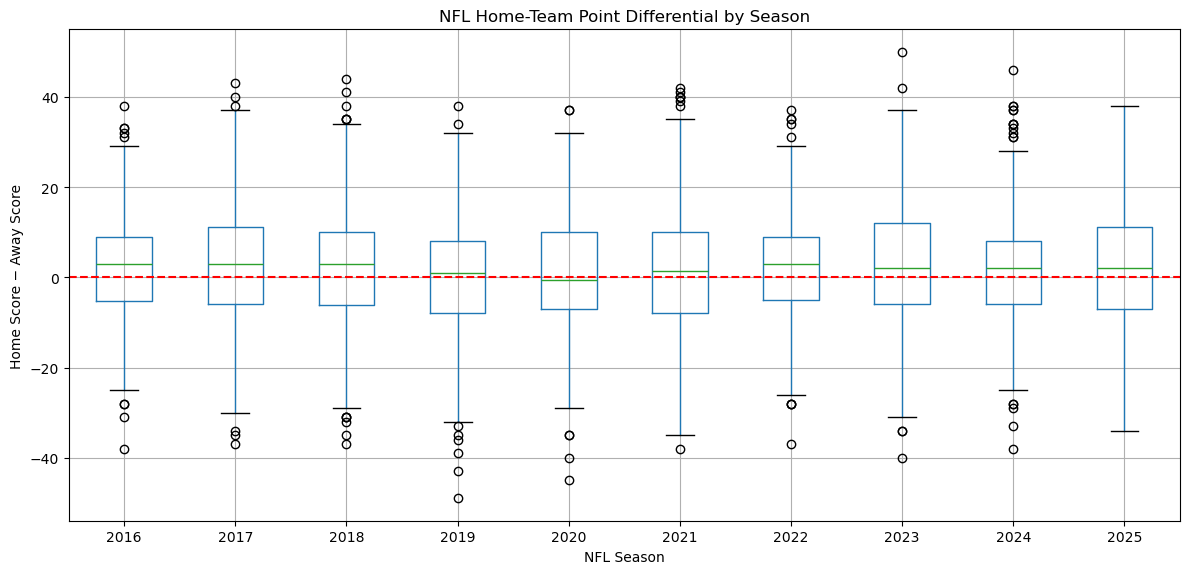

In [28]:
# Box plot: home-team point differential by season
final_df.boxplot(
    column="Point Differential",
    by="Season",
    figsize=(12, 6)
)

plt.axhline(y=0, color="red", linestyle="--")
plt.title("NFL Home-Team Point Differential by Season")
plt.suptitle("")
plt.xlabel("NFL Season")
plt.ylabel("Home Score − Away Score")
plt.tight_layout()
plt.show()

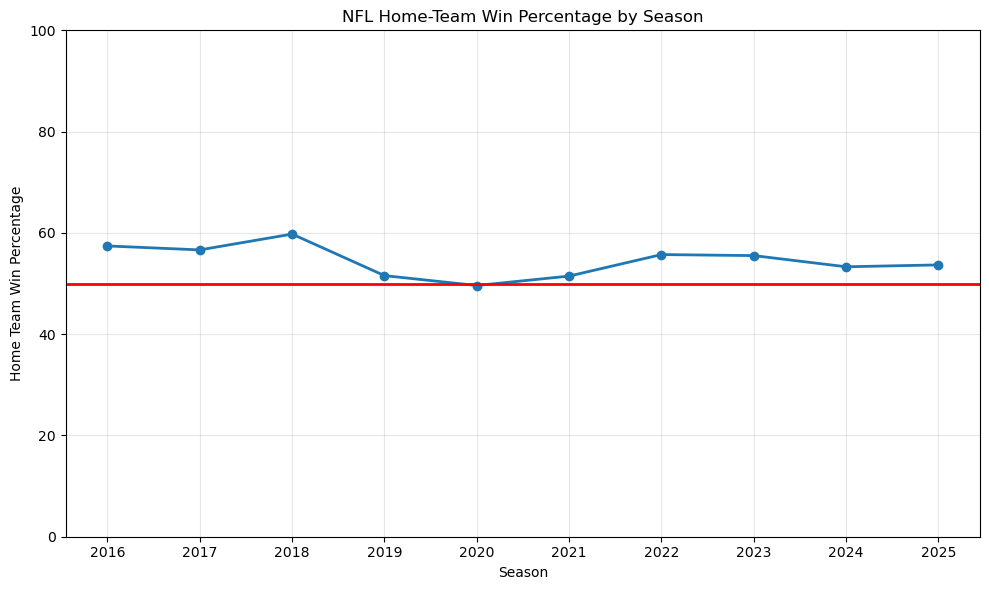

In [36]:
# Line plot: home-team win percentage by season
plt.figure(figsize=(10, 6))

plt.plot(
    home_win_percentage["Season"],
    home_win_percentage["Home Win Percentage"],
    marker="o",
    linewidth=2
)

plt.axhline(y=50, color="red", linestyle="-", linewidth=2)

plt.title("NFL Home-Team Win Percentage by Season")
plt.xlabel("Season")
plt.ylabel("Home Team Win Percentage")
plt.ylim(0, 100)
plt.xticks(home_win_percentage["Season"])
plt.grid(True, alpha=0.3)

import os

os.makedirs("images", exist_ok=True)

plt.savefig(
    "images/home_win_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig("images/home_win_percentage.png")

plt.tight_layout()
plt.show()

In [30]:
# Save the cleaned project dataset and summary table
final_df.to_csv("nfl_home_field_advantage_2016_2025.csv", index=False)
home_win_percentage.to_csv("nfl_home_win_percentage_by_season.csv", index=False)

print("Saved:")
print("- nfl_home_field_advantage_2016_2025.csv")
print("- nfl_home_win_percentage_by_season.csv")

Saved:
- nfl_home_field_advantage_2016_2025.csv
- nfl_home_win_percentage_by_season.csv
